Gay Merino, Florencia.
Rodriguez Camps, Maximiliano

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

#Ejercicio 4


Comentario antes de leer estos codigos:
El codigo de como esta expresado cada u= u_(a,b,c,d) esta en el celda de la trayectoria de cada uno. La manera correcta de correr todo, es hacerlo secuencialmente, si por ejemplo se corre el grafico de trayectoria para u_a y luego se quiere correr las lineas de corriente de u_c, el grafico que se muestre sera el de a y no el de c. Habria que volver a correr la trayectoria de c para ver posteriormente las lineas de corriente de c.
 Si la celda tarda mucho en correrse, bajar el numero de N o subir el ds

In [ ]:
#@title codigo para RK2


def esquema(X, u, t, dt):
  """
  Calcula X(t+dt) a partir de X(t) y el campo de velocidades.

  Parámetros:
    X : Solución a tiempo t (X(t)) cómo arreglo de dimensión dX′dt′=cos(y′)x^+cos(xX′dt′=cos(y′)x^+cos(x′)y^′)y^
    u : Campo de velocidades cómo función de (x,RK2t)
    t : Tiempo donde se conoce t
    dt: Paso temporal
  """
  k1= u(X,t)
  k2= u(X+k1*dt/2,t+dt/2)
  X= X+k2*dt

  return X

In [ ]:
#@title  Codigo para trayectorias y lineas de corriente
def trayectoria(X0, u, N, dt):

  d = X0.shape[0]            # Dimensión del problema
  ts = np.arange(0, N+1)*dt  # Tiempos donde calcularé la solución
  Xs = np.zeros((N+1, d))    # Solución aproximada
  Xs[0] = X0                 # Impongo la condición inicial a t=0
  for j in range(N):
    # Aplico esquema anterior sobre Xs[j] para obtener Xs[j+1]
    Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
  return ts, Xs

def linea_de_corriente(l0, u, t, N, ds):
  """
  Calcula numéricamente la solución a dX/ds = u(X,t) cómo
  un arreglo, usando el esquema definido previamente

  Parámetros:
    l0: Origen de la línea cómo arreglo de dimensión d
    u : Campo de velocidades cómo función de (x,t)
    t : Tiempo para el cual se está calculando la línea
    N : Número de pasos en s
    ds: Paso del parametrizador
  """
  d = l0.shape[0]            # Dimensión del problema
  s = np.arange(0, N+1)*ds   # Valores del parametrizador s
  ls = np.zeros((N+1, d))    # Solución aproximada a lo largo de s
  ls[0] = l0                 # Impongo la condición inicial a s=0
  for j in range(N):
    # Aplico esquema sobre ls[j] para obtener ls[j+1]
    ls[j+1] = esquema(ls[j], u, t, ds)
  return s, ls


##4a
$$
\vec{U}(x, y, t) = a \hat{x} + b \cos \left( \frac{2 \pi t}{\tau} \right) \hat{y}
$$



**Líneas de corriente:**
$\frac{dx}{u_x} = \frac{dy}{u_y}$

$$
\frac{dx}{a} = \frac{dy}{b \cos \left( \frac{2 \pi t}{\tau} \right)}
$$

$$
\frac{b}{a} \int_{x_0}^{x} \cos \left( \frac{2 \pi t}{\tau} \right) dx' = \int_{y_0}^{y} dy'
$$

$$
y(x) = \frac{b}{a} \cos \left( \frac{2 \pi t}{\tau} \right) (x - x_0) + y_0
$$

**Trayectorias:**
$\frac{\partial \vec{X}}{\partial t} = \left( \frac{dx}{dt}, \frac{dy}{dt} \right)$

$$
\int_{x_0}^{x} dx' = \int_0^{t} a \, dt', \quad x(t) = x_0 + a t, \quad t = \frac{x - x_0}{a}
$$

$$
\int_{y_0}^{y} dy' = \int_0^{t} b \cos \left( \frac{2 \pi t'}{\tau}
\right) dt'
$$

$$
y(t) = \frac{b\tau}{2 \pi} \sin \left( \frac{2 \pi t}{\tau} \right) + y_0
$$

$$
y(x) = \frac{b\tau}{2 \pi} \sin \left( \frac{2\pi}{τ} \frac{x - x_0}{a} \right) + y_0
$$

**Líneas de traza:**
$(x_r, y_r)$ a $ t = t'$

$$
x_r = a t' + x_0, \quad x_0 = x_r - a t'
$$

$$
x(t) = a t + x_r - a t' = x_r + a (t - t')
$$

$$
\frac{x - x_r}{a} + t' = t
$$

$$
y_r = \frac{b \, \tau}{2 \pi} \sin \left( \frac{2 \pi t'}{\tau} \right) + y_0
$$

$$
y_0 = y_r - \frac{b \, \tau}{2 \pi} \sin \left( \frac{2 \pi t'}{\tau} \right)
$$

$$
y(t) = y_r  - \frac{b \, \tau}{2 \pi} \left( \sin \left( \frac{2 \pi t'}{\tau} \right) - \sin \left( \frac{2 \pi t}{\tau} \right) \right)
$$

$$
y(x) = y_r - \frac{b \, \tau}{2 \pi} \left( \sin \left( \frac{2 \pi t'}{\tau} \right) - \sin \left( \frac{2\pi}{\tau} \frac{x - x_r }{a}+t' \right)
\right)
$$


(-1.0, 1.0)

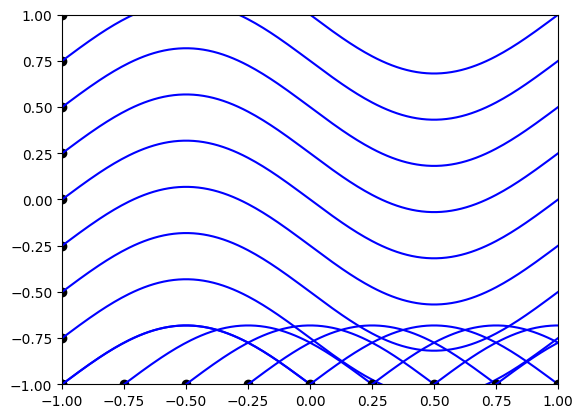

In [ ]:
#@title Grafico de trayectoria para el 4a
a=1
u = lambda x, t: np.array([a, np.cos(np.pi*t)])
N = 200
ds = 1e-2
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)
for i in range(l0s.shape[0]):
  t, Xs = trayectoria(l0s[i], u, 200, 1e-2)
  plt.plot(Xs[0,0], Xs[0,1], "ko")
  plt.plot(Xs[:,0], Xs[:,1], "b-")
plt.xlim(-1, 1)
plt.ylim(-1, 1)

In [ ]:
#@title codigo para lineas de corriente y grafico para el 4a

def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de campo y las grafica en
  un video a medida que avanza el tiempo. Asume que existe
  una funcion 'linea_de_corriente' previamente definida.

  Parámetros:
    l0s: Origen de las líneas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    ts : Tiempos para los cuales se calculan las líneas cómo
         arreglo de dimensión m
    N  : Número de pasos en s
    ds : Paso del parametrizador
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = l0s.shape[0]   # Cantidad de líneas de corriente
  m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
  ls = np.zeros((m, n, N+1, 2))
  for i in range(m):
    for j in range(n):
      _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)
  xs = ls[:,:,:,0]
  ys = ls[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams
  plt.rc('animation', html='jshtml')

  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t} de {m}",
          end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, m), blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
ts = np.linspace(0, 2, 21)
evolucionar_lineas(l0s, ts, u, N, ds, ext=[-1,1,-1,1], figsize=None)

Calculando fotograma 20 de 21

[Animacion interactiva removida por tamano]

In [ ]:
#@title Codigo de trazas y grafica para el 4a
def evolucionar_trazas(X0s, u, N, dt, paso=1, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de traza y las grafica
  en un video a medida que avanza el tiempo. Asume que
  existe una funcion 'esquema' previamente definida.

  Parámetros:
    X0s: Origen de las trazas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    N  : Número de pasos temporales
    dt : Paso temporal
   paso: Cantidad de pasos temporales entre fotogramas
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = X0s.shape[0]   # Cantidad de líneas de traza
  ts = np.arange(N+1)*dt
  Xs = np.zeros((N+1, n, N+1, 2))
  for j in range(n):
    Xs[:, j] = X0s[None, j, None]
    for i in range(N):
      for k in range(i//paso+1):
        Xs[i+1, j, k] = esquema(Xs[i, j, k], u, ts[i], dt)
  xs = Xs[:,:,:,0]
  ys = Xs[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams

  ValueError: set
  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas

  ValueError: set
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t//paso} de {(N+1)//paso}", end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, N+1, paso),
                                 blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
dt = 1e-2
evolucionar_trazas(l0s, u, N, dt, paso=10, ext=[-1,1,-1,1], figsize=None)


Calculando fotograma 20 de 20

[Animacion interactiva removida por tamano]

##4b

$$
\vec{u(\vec{x},t)}=\frac{\alpha x}{1+\beta t}\hat{x} + c\hat{y}
$$



**Líneas de corriente:**
$\frac{dx}{u_x} = \frac{dy}{u_y}$

$$
\frac{cdx}{\alpha x}(1+\beta t)=dy
$$

Integrando desde $(x_0,y_0)$ hasta (x,y):

$$
\frac{c(1+\beta t)}{\alpha} \int_{xo}^{x} \frac{1}{x} \,dx \ = \int_{yo}^{y} \,dy \
$$

$$
y(x)=y_0 + \frac{c(1+\beta t)}{\alpha}\ln(\left|\frac{x}{x_0}\right|)
$$



**Trayectorias:**
$\frac{\partial \vec{X}}{\partial t} = \left( \frac{dx}{dt}, \frac{dy}{dt} \right)$
$$
\frac{\partial X}{\partial t}=u_x(x,y,t), \frac{\partial Y}{\partial t}=u_y(x,y,t)
$$
$$
\frac{\partial X}{\partial t}=\frac{\alpha x}{1+ \beta t}
$$

$$
\frac{dx}{dt}=\frac{\alpha x}{1+ \beta t}
$$

$$
\frac{1+ \beta t}{dt}=\frac{dx}{\alpha x}
$$

$$
\frac{1}{\alpha}\ln(\frac{x}{x_0})=\frac{1}{\beta}\ln(1+\beta t)
$$

$$
x(t)=x_0(1+ \beta t)^{\frac{\alpha}{\beta})}
$$

$$
\frac{dy}{dt}=c
$$


$$
y(t)= y_0+ct
$$
$$
y(x)=y_0+ \frac{c}{\beta}[(\frac{x}{x_0})^{\frac{\beta}{\alpha}} -1]
$$

**Lineas de traza:**
$(x_r,y_r)$ a $t=t'$

$$
x_r = x_0 (1+\beta t')^{\frac{\alpha}{\beta}}, y_r= y_0 +ct'
$$

$$
x_0=x(t)=x_r \frac{(1+\beta t)}{(1+\beta t')}
$$

$$
y(t)=y_r+c(t-t')
$$




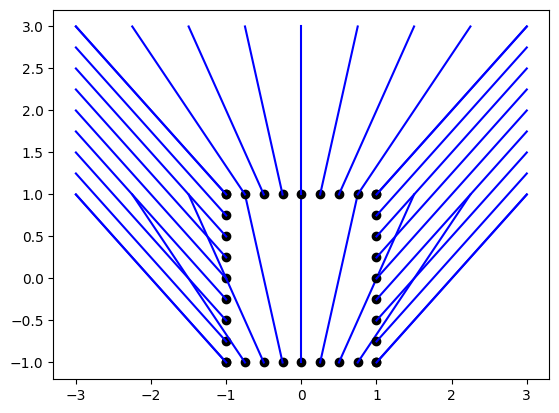

In [ ]:
#@title Grafico de trayectoria para el 4b
c=1
u = lambda x, t: np.array([x[0]/(1+t), c*1])
N = 200
ds = 1e-2
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)] + [[1, a] for a in np.linspace(-1, 1, 9)] + [[a, 1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)
for i in range(l0s.shape[0]):
  t, Xs = trayectoria(l0s[i], u, 200, 1e-2)
  plt.plot(Xs[0,0], Xs[0,1], "ko")
  plt.plot(Xs[:,0], Xs[:,1], "b-")
# plt.xlim(-1, 1)
# plt.ylim(-1, 1)

In [ ]:
#@title codigo para lineas de corriente y grafico para el 4b

def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de campo y las grafica en
  un video a medida que avanza el tiempo. Asume que existe
  una funcion 'linea_de_corriente' previamente definida.

  Parámetros:
    l0s: Origen de las líneas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    ts : Tiempos para los cuales se calculan las líneas cómo
         arreglo de dimensión m
    N  : Número de pasos en s
    ds : Paso del parametrizador
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = l0s.shape[0]   # Cantidad de líneas de corriente
  m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
  ls = np.zeros((m, n, N+1, 2))
  for i in range(m):
    for j in range(n):
      _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)
  xs = ls[:,:,:,0]
  ys = ls[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams
  plt.rc('animation', html='jshtml')

  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t} de {m}",
          end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")


    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, m), blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
ts = np.linspace(0, 2, 21)
evolucionar_lineas(l0s, ts, u, N, ds, ext=[-1,1,-1,1], figsize=None)

Calculando fotograma 20 de 21

[Animacion interactiva removida por tamano]

In [ ]:
#@title Codigo de trazas y grafica para el 4b
def evolucionar_trazas(X0s, u, N, dt, paso=1, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de traza y las grafica
  en un video a medida que avanza el tiempo. Asume que
  existe una funcion 'esquema' previamente definida.

  Parámetros:
    X0s: Origen de las trazas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    N  : Número de pasos temporales
    dt : Paso temporal
   paso: Cantidad de pasos temporales entre fotogramas
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = X0s.shape[0]   # Cantidad de líneas de traza
  ts = np.arange(N+1)*dt
  Xs = np.zeros((N+1, n, N+1, 2))
  for j in range(n):
    Xs[:, j] = X0s[None, j, None]
    for i in range(N):
      for k in range(i//paso+1):
        Xs[i+1, j, k] = esquema(Xs[i, j, k], u, ts[i], dt)
  xs = Xs[:,:,:,0]
  ys = Xs[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams

  ValueError: set
  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas

  ValueError: set
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t//paso} de {(N+1)//paso}", end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, N+1, paso),
                                 blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
dt = 1e-2
evolucionar_trazas(l0s, u, N, dt, paso=10, ext=[-1,1,-1,1], figsize=None)


Calculando fotograma 20 de 20

[Animacion interactiva removida por tamano]

##4c

fuente lineal constante :
$$
u(r,\theta)=\frac{Q}{2\pi r}\hat{r}
$$
una corriente uniforme que aumenta en el tiempo
$$
u(x,t)=u_0t\hat{x}
$$

$$
\hat{r}=(cos(\theta)\hat{x}+sen(\theta)\hat{y})
$$


$$
u=\frac{Q}{2\pi r}(cos(\theta)\hat{x}+sen(\theta)\hat{y}) + u_0t
$$

$$
rcos(\theta)=x
$$
$$
rsen(\theta)=y
$$
$$
cos(\theta)=\frac{x}{r}
$$
$$
sen(\theta)=\frac{y}{r}
$$

$$
u=\frac{Q}{2\pi r}(\frac{x}{r}\hat{x}+\frac{y}{r}\hat{y}) +u_0t\hat{x}
$$

$r^2=x^2+y^2$

$$
u=(\frac{Qx}{2\pi r^2}+u_0t)\hat{x} + (\frac{Qx}{2\pi r^2})\hat{y}
$$

In [ ]:
#@title Grafico de trayectoria para el 4c
Q = 1
L = 1
U0 = 1

u = lambda x, t: np.array([( Q/(2*np.pi*L**2*U0))*(x[0]/(x[0]**2+(x[1]**2)))+t,( Q/(2*np.pi*L**2*U0))*(x[1]/(x[0]**2+(x[1]**2))) ])

N = 2000
ds = 1e-6
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)
for i in range(l0s.shape[0]):
  t, Xs = trayectoria(l0s[i], u, 200, 1e-2)
  plt.plot(Xs[0,0], Xs[0,1], "ko")
  plt.plot(Xs[:,0], Xs[:,1], "b-")
plt.xlim(-1, 1)
plt.ylim(-1, 1)

In [ ]:
#@title codigo para lineas de corriente y grafico para el 4c

def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de campo y las grafica en
  un video a medida que avanza el tiempo. Asume que existe
  una funcion 'linea_de_corriente' previamente definida.

  Parámetros:
    l0s: Origen de las líneas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    ts : Tiempos para los cuales se calculan las líneas cómo
         arreglo de dimensión m
    N  : Número de pasos en s
    ds : Paso del parametrizador
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = l0s.shape[0]   # Cantidad de líneas de corriente
  m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
  ls = np.zeros((m, n, N+1, 2))
  for i in range(m):
    for j in range(n):
      _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)
  xs = ls[:,:,:,0]
  ys = ls[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams
  plt.rc('animation', html='jshtml')

  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t} de {m}",
          end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")


    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, m), blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
ts = np.linspace(0, 2, 21)
evolucionar_lineas(l0s, ts, u, N, ds, ext=[-1,1,-1,1], figsize=None)

KeyboardInterrupt: 

In [ ]:
#@title Codigo de trazas y grafica para el 4c
def evolucionar_trazas(X0s, u, N, dt, paso=1, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de traza y las grafica
  en un video a medida que avanza el tiempo. Asume que
  existe una funcion 'esquema' previamente definida.

  Parámetros:
    X0s: Origen de las trazas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    N  : Número de pasos temporales
    dt : Paso temporal
   paso: Cantidad de pasos temporales entre fotogramas
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = X0s.shape[0]   # Cantidad de líneas de traza
  ts = np.arange(N+1)*dt
  Xs = np.zeros((N+1, n, N+1, 2))
  for j in range(n):
    Xs[:, j] = X0s[None, j, None]
    for i in range(N):
      for k in range(i//paso+1):
        Xs[i+1, j, k] = esquema(Xs[i, j, k], u, ts[i], dt)
  xs = Xs[:,:,:,0]
  ys = Xs[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams

  ValueError: set
  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas

  ValueError: set
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t//paso} de {(N+1)//paso}", end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, N+1, paso),
                                 blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
dt = 1e-2
evolucionar_trazas(l0s, u, N, dt, paso=10, ext=[-1,1,-1,1], figsize=None)


Calculando fotograma 20 de 20

[Animacion interactiva removida por tamano]

##4d

sumidero lineal:

$$
u(r,\theta)=-\frac{Q}{2\pi r}\hat{r}
$$

torbellino con circulacion constante:
$$
u(r,\theta)= \frac{\Gamma}{2\pi r }\hat{\theta}
$$

torbellino que decrece exponencialmente con un tiempo caracteristico $\tau:$

$$
u(r,\theta)=\frac{\Gamma}{2\pi r }e^{-t/\tau}\hat{\theta}
$$

$$
u(r,\theta)=\frac{Q}{2\pi r}\hat{r} +\frac{\Gamma}{2\pi r }e^{-t/\tau}\hat{\theta}
$$




(-1.0, 1.0)

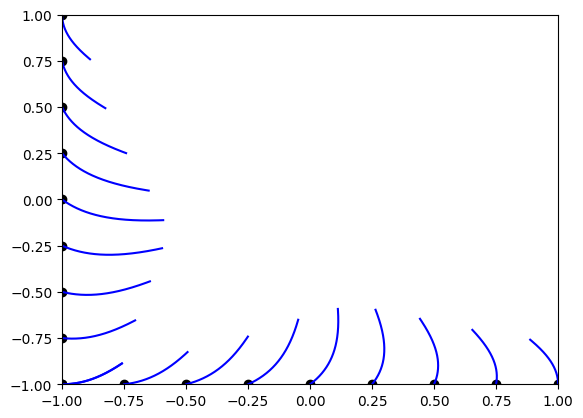

In [ ]:
#@title Grafico de trayectoria para el 4d
Q = 1
L = 1
U0 = 1
R=1
tau=1


u = lambda x, t: np.array([( -Q/(2*np.pi*L**2*U0))*(x[0]/(x[0]**2+(x[1]**2)))- (R*np.exp(-t/tau))/(2*np.pi*L**2*U0)*((x[1])/(x[0]**2+(x[1]**2))),( -Q/(2*np.pi*L**2*U0))*(x[1]/(x[0]**2+(x[1]**2)))+ (R*np.exp(-t/tau))/(2*np.pi*L**2*U0)*((x[0])/(x[0]**2+(x[1]**2))) ])

N = 6000
ds = 1e-3
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)
for i in range(l0s.shape[0]):
  t, Xs = trayectoria(l0s[i], u, 200, 1e-2)
  plt.plot(Xs[0,0], Xs[0,1], "ko")
  plt.plot(Xs[:,0], Xs[:,1], "b-")
plt.xlim(-1, 1)
plt.ylim(-1, 1)

In [ ]:
#@title codigo para lineas de corriente y grafico para el 4d

def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de campo y las grafica en
  un video a medida que avanza el tiempo. Asume que existe
  una funcion 'linea_de_corriente' previamente definida.

  Parámetros:
    l0s: Origen de las líneas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    ts : Tiempos para los cuales se calculan las líneas cómo
         arreglo de dimensión m
    N  : Número de pasos en s
    ds : Paso del parametrizador
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = l0s.shape[0]   # Cantidad de líneas de corriente
  m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
  ls = np.zeros((m, n, N+1, 2))
  for i in range(m):
    for j in range(n):
      _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)
  xs = ls[:,:,:,0]
  ys = ls[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams
  plt.rc('animation', html='jshtml')

  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t} de {m}",
          end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")


    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, m), blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
ts = np.linspace(0, 2, 21)
evolucionar_lineas(l0s, ts, u, N, ds, ext=[-1,1,-1,1], figsize=None)

Calculando fotograma 20 de 21

[Animacion interactiva removida por tamano]

In [ ]:
#@title Codigo de trazas y grafica para el 4d
def evolucionar_trazas(X0s, u, N, dt, paso=1, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de traza y las grafica
  en un video a medida que avanza el tiempo. Asume que
  existe una funcion 'esquema' previamente definida.

  Parámetros:
    X0s: Origen de las trazas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    N  : Número de pasos temporales
    dt : Paso temporal
   paso: Cantidad de pasos temporales entre fotogramas
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = X0s.shape[0]   # Cantidad de líneas de traza
  ts = np.arange(N+1)*dt
  Xs = np.zeros((N+1, n, N+1, 2))
  for j in range(n):
    Xs[:, j] = X0s[None, j, None]
    for i in range(N):
      for k in range(i//paso+1):
        Xs[i+1, j, k] = esquema(Xs[i, j, k], u, ts[i], dt)
  xs = Xs[:,:,:,0]
  ys = Xs[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams

  ValueError: set
  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas

  ValueError: set
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t//paso} de {(N+1)//paso}", end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, N+1, paso),
                                 blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim
dt = 1e-2
evolucionar_trazas(l0s, u, N, dt, paso=10, ext=[-1,1,-1,1], figsize=None)


Calculando fotograma 153 de 600

Calculando fotograma 600 de 600

[Animacion interactiva removida por tamano]

#EJERCICIO 12
Ecuacion de Euler de la estrella

##12.1

$$
\rho \left[\frac{\partial \vec{U}}{\partial t} + (\vec{U} \cdot \nabla)\vec{U}\right] = \vec{F} -\nabla P
$$

$$
\vec{F}=\rho \vec{g}
$$
**Equilibrio hidrostático:**

$$
\vec{U} = 0
$$

$$
\vec{F} = \nabla P
$$

$$
\vec{\nabla} \cdot \vec{g} = -4\pi G \rho
$$

$$
\iiint \vec{\nabla} \cdot \vec{g} \, dV = \iiint -4\pi G \rho \, dV
$$

$$
\oint \vec{g} \cdot d\vec{A} = -4\pi G \iiint \rho \, dV
$$

$$
4\pi g r^2 = -8\pi^2 G \int_0^r \rho r^2 dr
$$

$$
g = -\frac{G M(r)}{r^2}
$$

**Ecuación de equilibrio:**

$$
-\frac{GM(r)}{r^2} = \frac{1}{\rho} \frac{dP}{dr}
$$


##12.2
Polítropo de índice n

$$
P = K \rho^{(n+1)/n}
$$

$$
\frac{1}{\rho} \frac{dP}{dr} = -\frac{GM(r)}{r^2}
$$

$$
\frac{1}{\rho} \frac{dP}{dr} = -\frac{G}{r^2} \int_0^r 4\pi \rho r^2 dr
$$

$$
\frac{d}{dr}(\frac{r^2}{\rho} \frac{dP}{dr}) = \frac{d}{dr}(-G \int_0^r 4\pi \rho r^2 dr)
$$




**Ecuación diferencial de la densidad de la estrella:**

$$
\frac{d}{dr}\left(\frac{r^2}{\rho} \frac{dP}{dr}\right) = -4\pi G \rho r^2
$$

##12.3
**Adimensionalización**

$$
r = a\xi, \quad \rho = \rho_c \theta^n, \quad P = K \rho^{(n+1)/n}
$$

$$
\frac{1}{\rho} \frac{dP}{dr} = -\frac{GM(r)}{r^2}
$$

$$
\frac{K\rho_c^{(n+1)/n}}{\theta^n\rho_c a} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{GM(r)}{a^2\xi^2}
$$

$$
\frac{K\rho_c^{1/n}}{\theta^n a} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{GM(r)}{a^2\xi^2}
$$

$$
\frac{\xi^2}{\theta^n a} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{GM(r)}{a^2 k\rho_c^{1/n}}
$$

$$
\frac{d}{d\xi}\frac{\xi^2}{\theta^n a} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{G}{a^2 k\rho_c^{1/n}}\frac{dM(r)}{d\xi}
$$

$$
\frac{d}{d\xi}\frac{\xi^2}{\theta^n a} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{G\rho_c\theta^n a\xi^2 4\pi}{k\rho_c^{1/n}}
$$

$$
\frac{d}{d\xi}\frac{\xi^2}{\theta^n} \frac{d\theta^{(n+1)}}{d\xi} = -\frac{G\rho_c^{1-1/n}\theta^n a^2\xi^2 4\pi}{k}
$$

$$
\frac{d}{d\xi}\frac{\xi^2 (n+1)\theta^n}{\theta^n} \frac{d\theta}{d\xi} = -\frac{G\rho_c^{1-1/n}\theta^n a^2\xi^2 4\pi}{k}
$$

$$
\frac{d}{d\xi} [\xi^2\frac{d\theta}{d\xi}] = -\frac{G\rho_c^{1-1/n}\theta^n a^2\xi^2 4\pi}{k(n+1)}
$$

$$
a^2=\frac{k(n+1)}{G\rho_c^{1-1/n}4\pi}
$$

$$
2\xi\frac{d\theta}{d\xi} + \xi^2\frac{d\theta^2}{d\xi^2}=-\theta^n\xi^2
$$
**Ecuacion de Lane Emden**:
$$
2\xi\frac{d\theta}{d\xi} + \xi^2\frac{d\theta^2}{d\xi^2}+\theta^n\xi^2=0
$$

#12.4
**Condiciones de contorno**

**primera**:
$$
\theta(\xi=0)=1
$$
equivale a:

$$
ρ(\xi=0)=\rho_c
$$
donde $\rho_c$ es la densidad en el centro de la estrella

**segunda:**

$$
\theta'(\xi=0)=1
$$

podemos llegar a esto apartir de aproximar la ecuacion de equilibrio y viendo en el origen:

$$
\frac{dp}{dr}=-\frac{G\rho M(r)}{r^2}
$$

$$
M(r)\approx \frac{4\pi r^3\rho_0}{g} ,\quad  \rho = \rho_c \theta^n, \quad P = K \rho^{(n+1)/n}
$$


$$
\frac{d\theta}{dr}\approx-\frac{r^3}{r^2}
$$

$$
\lim_{\xi\rightarrow0}\frac{d\theta}{d\xi}=0
$$

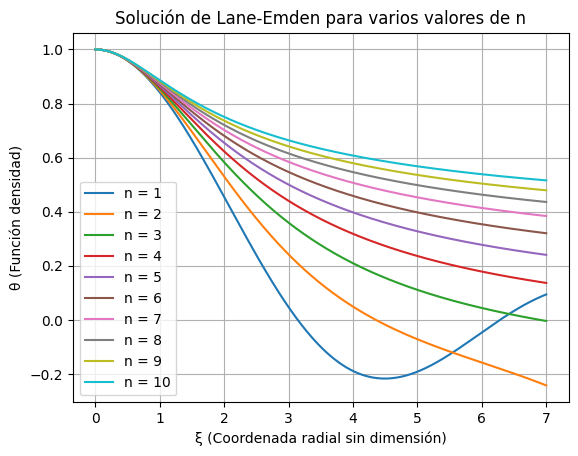

In [ ]:
#@title 12.5
#voy a linealizar mi ecuacion de 2do orden:
# voy a cambiar las letras a etha la voy a llamar x , y las titas por y
# llame y_1 a tita y y_2 la derivada de tita
def lin(Y, x, n):
    y_1 =Y[0]
    y_2 = Y[1]
    dy_1dx = y_2
    if x == 0:
        dy_2dx = 0  #por si me tira error
    else:
        dy_2dx = -(2/x) * y_2 - y_1**n

    return np.array([dy_1dx, dy_2dx])

# ahora voy con el RK4
def RK4(Y0, x0, xf, f, N, n):
    Y = np.zeros((N+1, len(Y0)))
    x = np.linspace(x0, xf, N+1)
    Y[0] = Y0
    h = x[1] - x[0]

    for i in range(N):
        k1 = f(Y[i], x[i], n)
        k2 = f(Y[i] + h*k1/2, x[i] + h/2, n)
        k3 = f(Y[i] + h*k2/2, x[i] + h/2, n)
        k4 = f(Y[i] + h*k3, x[i] + h, n)
        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        Y[i+1] = Y[i] + h * k

    return x, Y

# Condiciones iniciales
Y0 = [1, 0]  # θ(0) = 1, θ'(0) = 0
x0 = 1e-5  # Valor chico para evitar problemas en x = 0
xf = 7  # Rango de ξ (coordenada radial sin dimensión)
N = 10000  # Número de pasos
valoresden = np.arange(1, 11)


# Iterar sobre diferentes valores de n
for n in valoresden:
    x, Y = RK4(Y0, x0, xf, lin, N, n)

    # Separar los resultados para θ (densidad) y θ' (derivada de θ)
    y_1 = Y[:, 0]  # θ
    y_2 = Y[:, 1]  # θ'

    # Graficar θ en función de x
    plt.plot(x, y_1, label=f'n = {n}')


# Configuración del gráfico
plt.xlabel("ξ (Coordenada radial sin dimensión)")
plt.ylabel("θ (Función densidad)")
plt.title("Solución de Lane-Emden para varios valores de n")
plt.legend()
plt.grid(True)
plt.show()

En el grafico podemos ver que los casos donde la estrella es finita son para N=1,2,3,4 ya que son los unicos valores donde hay un valor de $\xi$, el radio adimensionalizado, donde $\theta$,la densidad adimencionalizada, vale 0. Fisicamente esto significa que la estrella en algun radio termina, para los demas casos la densidad nunca se hace 0 por lo que la estrella seria infinita.

##12.6

Grafico de la masa para valores finitos:

$$
M(r)= \int_0^r \rho r^2 4\pi \mathrm{d}r
$$

$$
M(\xi)= \int_0^\xi \rho_c \theta^n a^3 \xi^2 4\pi \mathrm{d}\xi
$$
De la ecuacion de Lane Emden:
$$
M(\xi)= \rho_c 4\pi a^3\int_0^\xi \xi^2 \theta^n\mathrm{d}\xi= \rho_c 4\pi a^3[\int_0^\xi 2\xi \frac{d\theta}{d\xi}\mathrm{d}\xi +\int_0^\xi \xi^2 \frac{d\theta}{d\xi}\mathrm{d}\xi]
$$
Integracion por partes del ultimo termino:

$$
\int_0^\xi \xi^2 \frac{d\theta}{d\xi}\mathrm{d}\xi=\xi^2\frac{d\theta(\xi)}{d\xi}-2\xi \frac{d\theta}{d\xi}\mathrm{d}\xi
$$

$$
M(\xi)=-\rho_c 4\pi a^3 \xi^2 \frac{d\theta(\xi)}{d\xi}
$$

apartir de este ultimo resultado podemos graficar $M(\xi)$ para los casos finitos


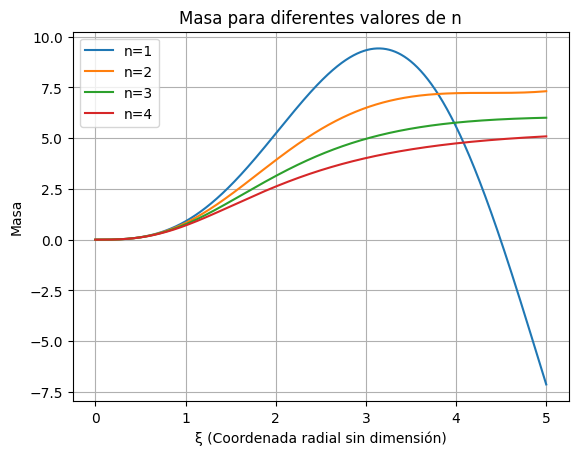

In [ ]:

def masa (Y,x,n):
  return -(x**2*Y[1])*3
# Condiciones iniciales
Y0 = [1, 0]  # θ(0) = 1, θ'(0) = 0 uso lo mismo que para el anterior
x0 = 1e-5  # Valor chico para evitar problemas en x = 0
xf = 5 # Rango de ξ (coordenada radial sin dimensión) si pongo mas se va n=2 al inf
N = 10000  # Número de pasos
valoresden = np.arange(1, 5) #lista de n=1,2,3,4

# Iterar sobre diferentes valores de n
for n in valoresden:
    x, Y = RK4(Y0, x0, xf, lin, N, n)  # Uso lin para obtener las soluciones de θ y θ'

    # Calcular la masa en función de x y Y
    masa_valores = -(x**2 * Y[:, 1])*3  # Calculo la masa usando Y[:, 1] (derivada de θ)

    # Graficar la masa en función de x
    plt.plot(x, masa_valores, label=f'n={n}')

# Configuración del gráfico
plt.xlabel("ξ (Coordenada radial sin dimensión)")
plt.ylabel("Masa")
plt.title("Masa para diferentes valores de n")
plt.legend()
plt.grid(True)
plt.show()